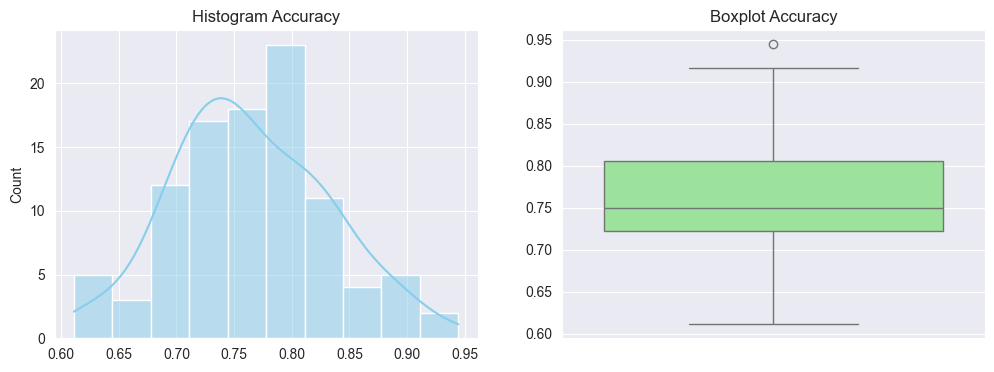

Średnia: 0.7639
95% Przedział ufności: [0.6389, 0.8889]


In [1]:
# --- ZADANIE 1 ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = load_wine()
X, y = data.data, data.target

n_iterations = 100
accuracies = []

for i in range(n_iterations):
    X_boot, y_boot = resample(X, y, replace=True)

    X_train, X_test, y_train, y_test = train_test_split(X_boot, y_boot, test_size=0.2)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    accuracies.append(knn.score(X_test, y_test))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(accuracies, kde=True, ax=ax1, color='skyblue')
ax1.set_title("Histogram Accuracy")
sns.boxplot(y=accuracies, ax=ax2, color='lightgreen')
ax2.set_title("Boxplot Accuracy")
plt.show()

print(f"Średnia: {np.mean(accuracies):.4f}")
print(f"95% Przedział ufności: [{np.percentile(accuracies, 2.5):.4f}, {np.percentile(accuracies, 97.5):.4f}]")

In [3]:
#--- ZADANIE 2 ---
import pandas as pd
df_wine = pd.DataFrame(data.data, columns=data.feature_names)
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


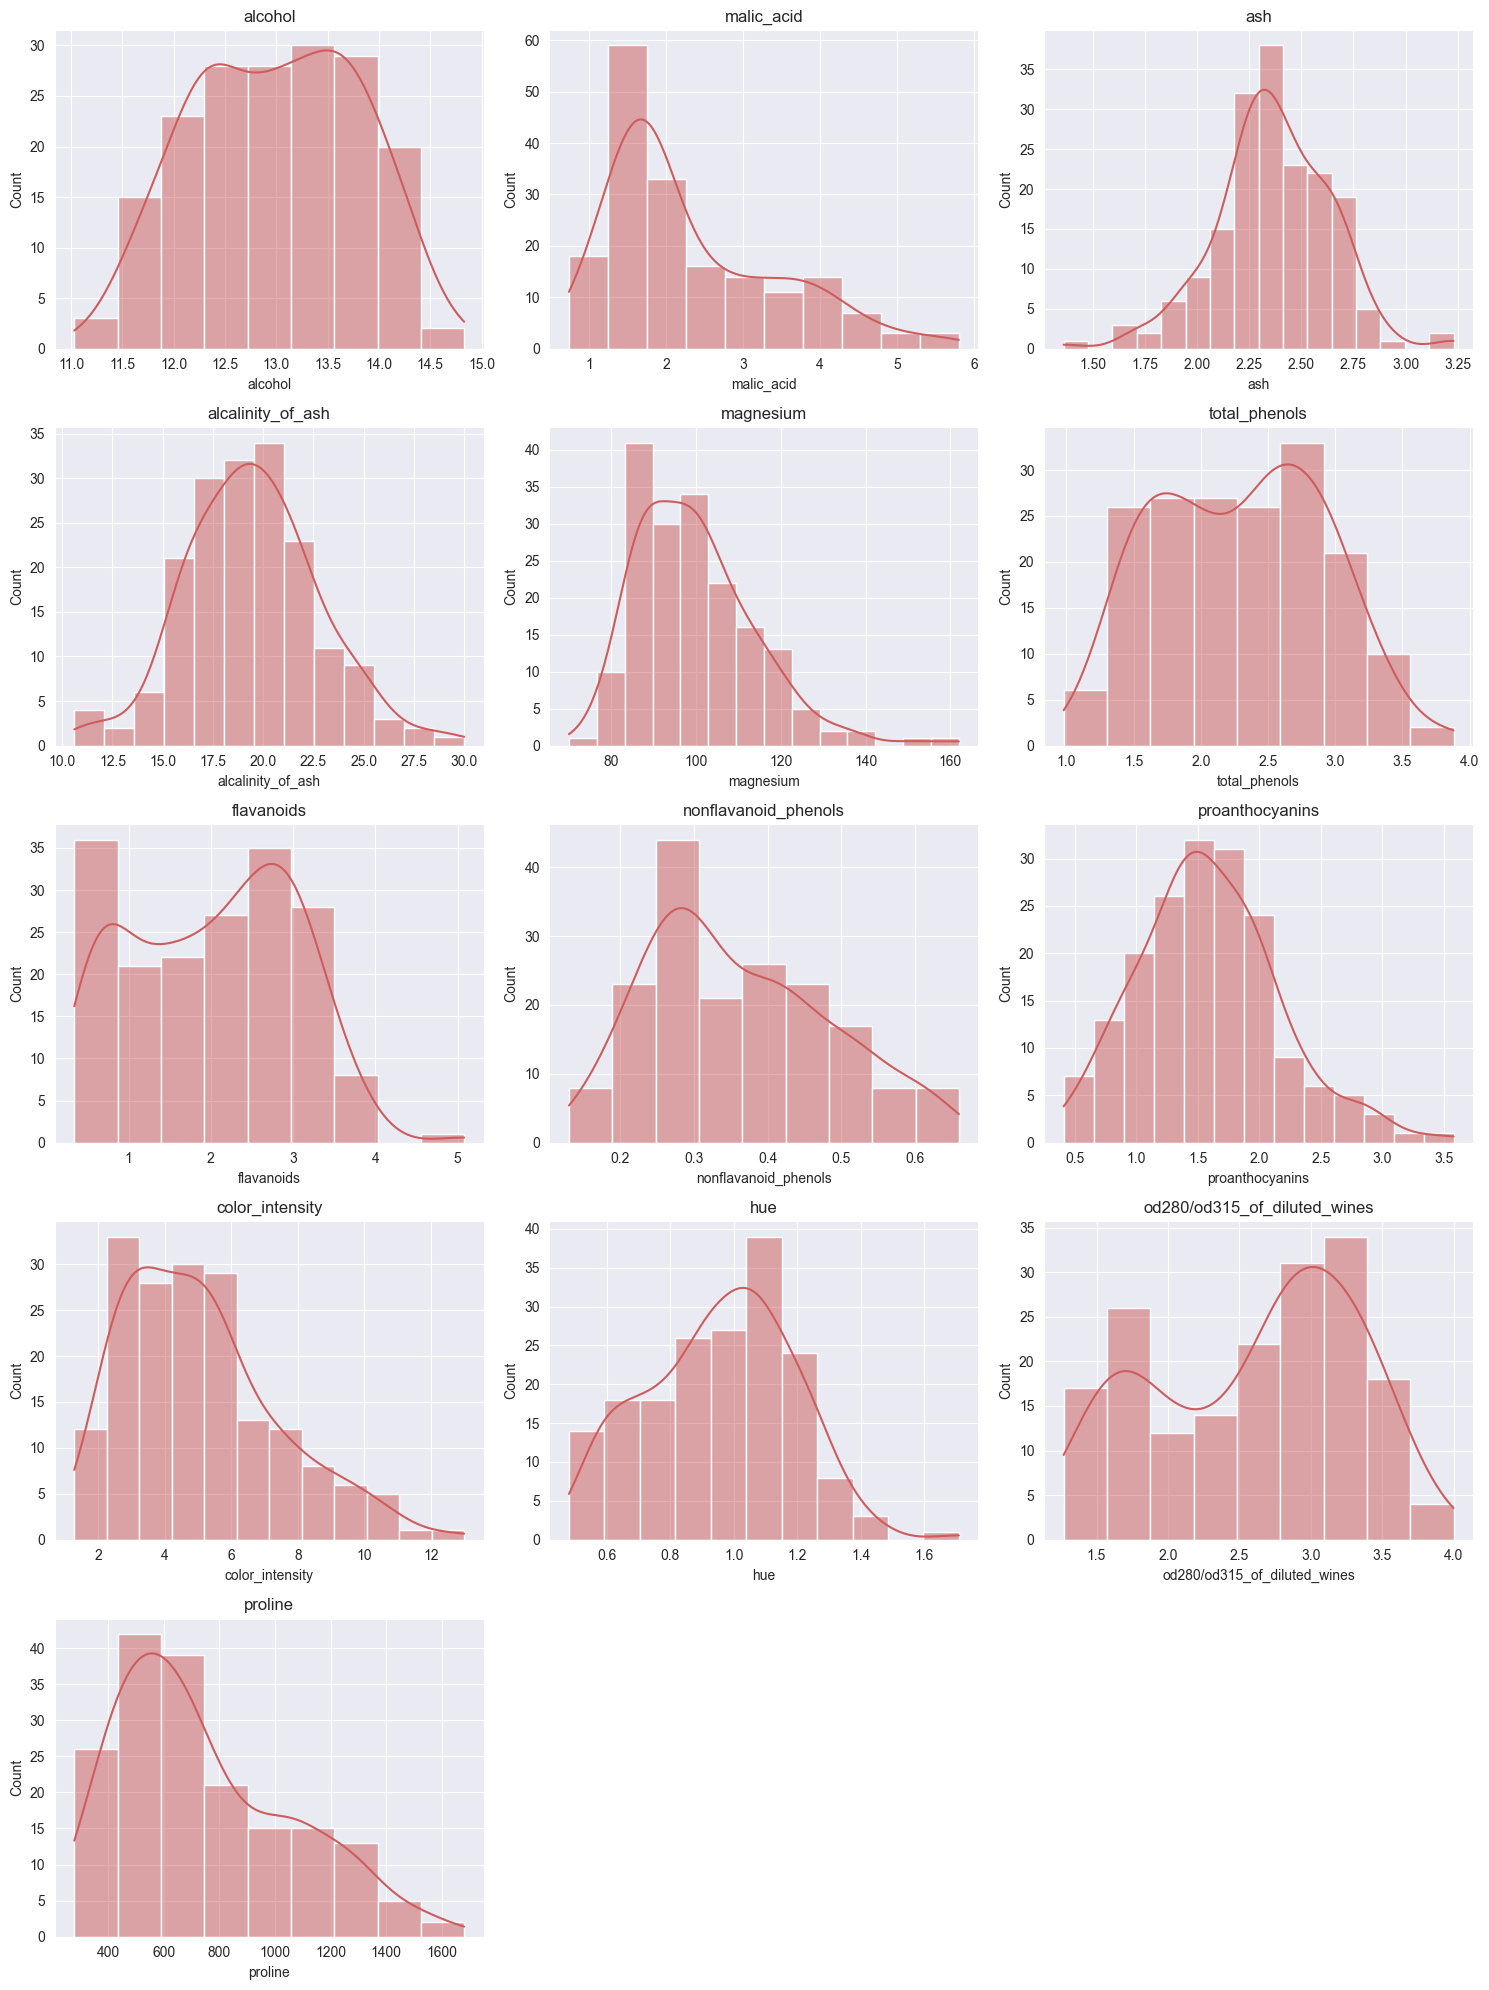

In [4]:
plt.figure(figsize=(15, 20))

for i, col in enumerate(df_wine.columns):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df_wine[col], kde=True, color='indianred')
    plt.title(col)

plt.tight_layout()
plt.show()

In [5]:
normal_features = [
    'alcalinity_of_ash',
    'ash',
    'pH'
]
not_normal_features = [
    'alcohol',
    'malic_acid',
    'magnesium',
    'total_phenols',
    'flavanoids',
    'nonflavanoid_phenols',
    'proanthocyanins',
    'color_intensity',
    'hue',
    'od280/od315_of_diluted_wines',
    'proline'
]

print(f"Liczba cech normalnych: {len(normal_features)}")
print(f"Liczba cech nienormalnych: {len(not_normal_features)}")

Liczba cech normalnych: 3
Liczba cech nienormalnych: 11


In [6]:
#--- ZADANIE 3 ---
pearson_corr = df_wine.corr(method='pearson')
pearson_corr.iloc[:5, :5]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575
ash,0.211545,0.164045,1.000000,0.443367,0.286587
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000


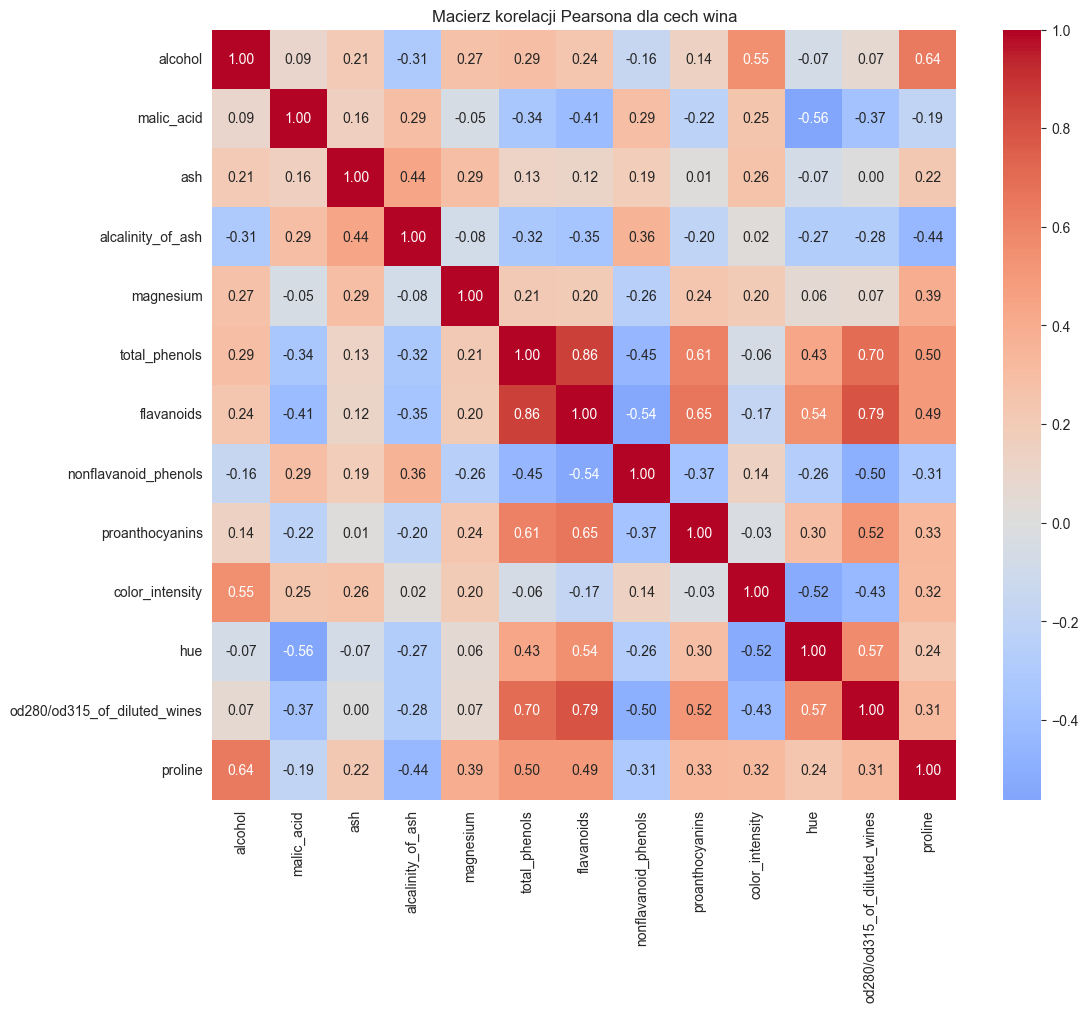

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Macierz korelacji Pearsona dla cech wina")
plt.show()

In [8]:
# --- ZADANIE 4 ---
spearman_corr = df_wine.corr(method='spearman')
kendall_corr = df_wine.corr(method='kendall')

spearman_corr.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.140430,0.243722,-0.306598,0.365503,0.310920,0.294740,-0.162207,0.192734,0.635425,-0.024203,0.103050,0.633580
malic_acid,0.140430,1.000000,0.230674,0.304069,0.080188,-0.280225,-0.325202,0.255236,-0.244825,0.290307,-0.560265,-0.255185,-0.057466
ash,0.243722,0.230674,1.000000,0.366374,0.361488,0.132193,0.078796,0.145583,0.024384,0.283047,-0.050183,-0.007500,0.253163
alcalinity_of_ash,-0.306598,0.304069,0.366374,1.000000,-0.169558,-0.376657,-0.443770,0.389390,-0.253695,-0.073776,-0.352507,-0.325890,-0.456090
magnesium,0.365503,0.080188,0.361488,-0.169558,1.000000,0.246417,0.233167,-0.236786,0.173647,0.357029,0.036095,0.056963,0.507575


In [9]:
diff_p_s = np.abs(pearson_corr.values - spearman_corr.values)
diff_p_k = np.abs(pearson_corr.values - kendall_corr.values)

diff_p_s_df = pd.DataFrame(diff_p_s, columns=df_wine.columns, index=df_wine.columns)
diff_p_k_df = pd.DataFrame(diff_p_k, columns=df_wine.columns, index=df_wine.columns)

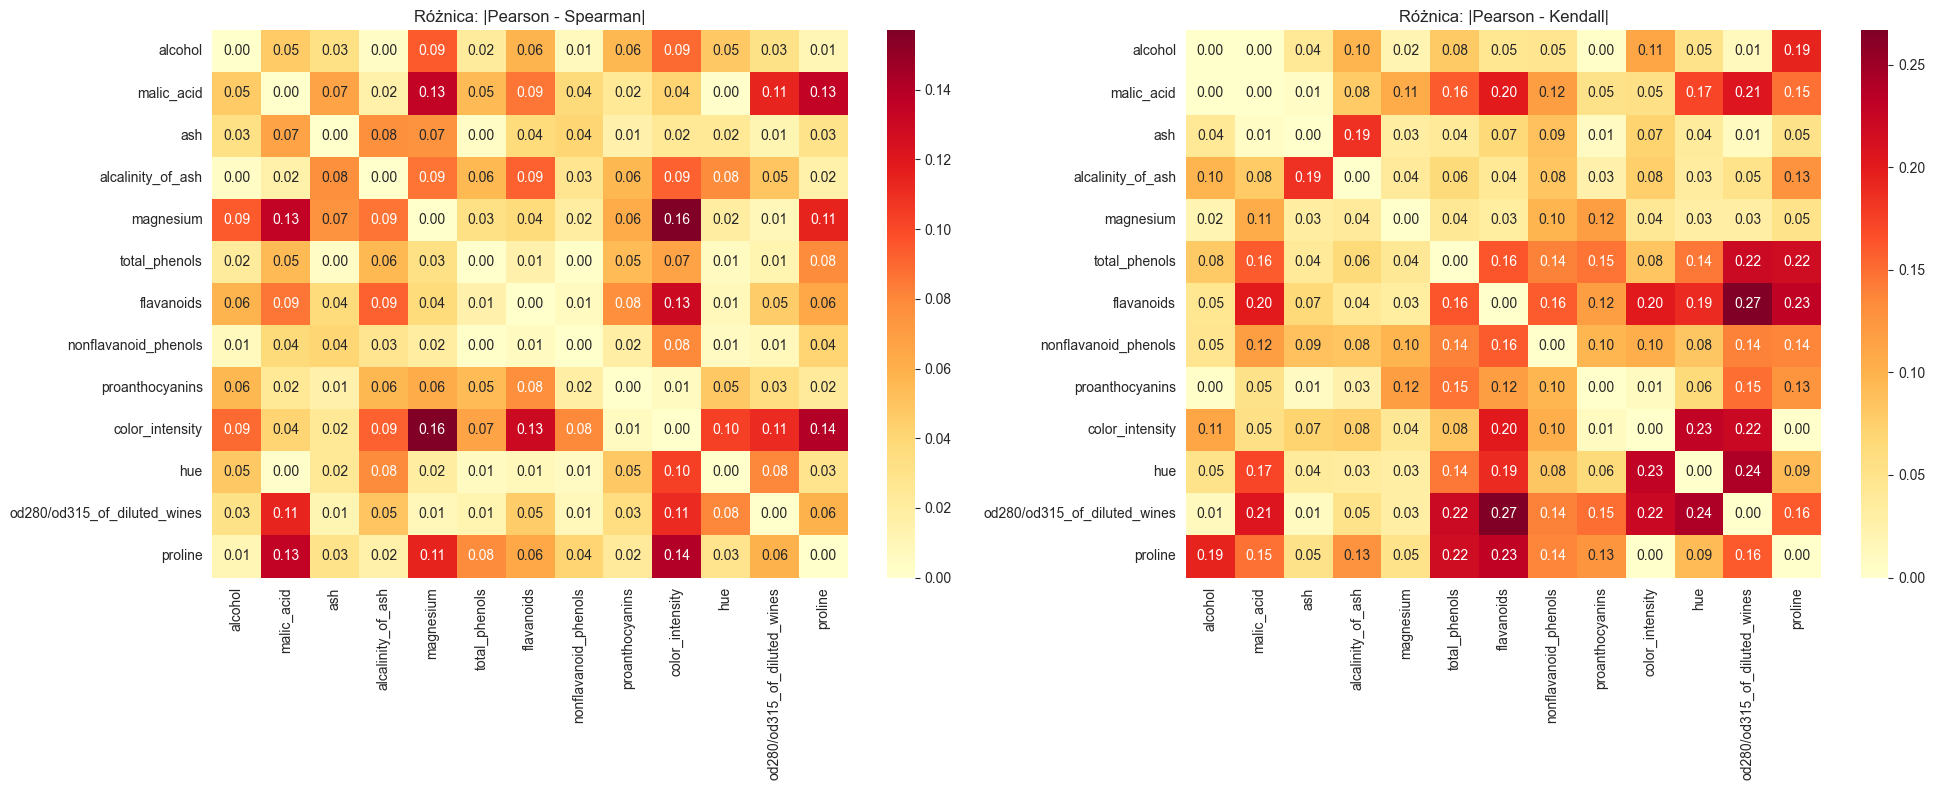

Cechy uznane za nienormalne w Zadaniu 2:
['alcohol', 'malic_acid', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(diff_p_s_df, annot=True, cmap='YlOrRd', ax=ax1, fmt=".2f")
ax1.set_title("Różnica: |Pearson - Spearman|")
sns.heatmap(diff_p_k_df, annot=True, cmap='YlOrRd', ax=ax2, fmt=".2f")
ax2.set_title("Różnica: |Pearson - Kendall|")
plt.tight_layout()
plt.show()
print("Cechy uznane za nienormalne w Zadaniu 2:")
print(not_normal_features)

In [12]:
# --- ZADANIE 5 ---
df_full = df_wine.copy()
df_full['Class'] = data.target

df_full.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [14]:
class_corr = df_full.corr(method='spearman')['Class']
class_corr = class_corr.drop('Class')
class_corr_sorted = class_corr.abs().sort_values(ascending=False)
print("Siła korelacji cech z atrybutem Class (od najsilniejszej):")
print(class_corr_sorted)

Siła korelacji cech z atrybutem Class (od najsilniejszej):
flavanoids                      0.854908
od280/od315_of_diluted_wines    0.743787
total_phenols                   0.726544
hue                             0.616570
proline                         0.576383
proanthocyanins                 0.570648
alcalinity_of_ash               0.569792
nonflavanoid_phenols            0.474205
alcohol                         0.354167
malic_acid                      0.346913
magnesium                       0.250498
color_intensity                 0.131170
ash                             0.053988
Name: Class, dtype: float64


Cechy o silnym wpływie na klasę (> 0.5): 7
flavanoids                      0.854908
od280/od315_of_diluted_wines    0.743787
total_phenols                   0.726544
hue                             0.616570
proline                         0.576383
proanthocyanins                 0.570648
alcalinity_of_ash               0.569792
Name: Class, dtype: float64


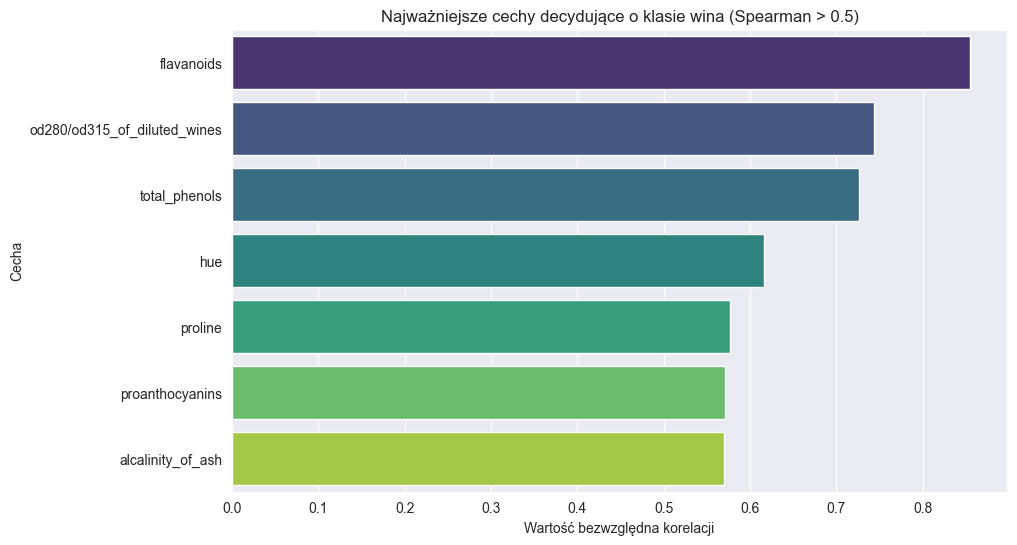

In [16]:
strong_features = class_corr_sorted[class_corr_sorted > 0.5]
print(f"Cechy o silnym wpływie na klasę (> 0.5): {len(strong_features)}")
print(strong_features)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=strong_features.values,
    y=strong_features.index,
    hue=strong_features.index,
    palette='viridis',
    legend=False
)

plt.title("Najważniejsze cechy decydujące o klasie wina (Spearman > 0.5)")
plt.xlabel("Wartość bezwzględna korelacji")
plt.ylabel("Cecha")
plt.show()